# 项目：分析鸢尾花种类数据

## 分析目标

此数据分析报告的目的是基于鸢尾花的属性数据，分析两种鸢尾花萼片的长度和宽度平均值，是否存在显著性差异，让我们可以对不同种类鸢尾花的属性特征进行推断。

## 简介

原始数据`Iris.csv`包括两种鸢尾花，每种有 50 个样本，以及每个样本的一些属性，包括萼片的长度和宽度、花瓣的长度和宽度。

`Iris.csv`每列的含义如下：
- Id：样本的ID。
- SepalLengthCm：萼片的长度（单位为厘米）。
- SepalWidthCm：萼片的宽度（单位为厘米）。
- PetalLengthCm：花瓣的长度（单位为厘米）。
- PetalWidthCm：花瓣的宽度（单位为厘米）。
- Species：鸢尾花种类。

## Access and Clean

In [35]:
import pandas as pd

from scipy.stats import ttest_ind

import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
original_data = pd.read_csv('Iris.csv')
original_data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [11]:
original_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             100 non-null    int64  
 1   SepalLengthCm  100 non-null    float64
 2   SepalWidthCm   100 non-null    float64
 3   PetalLengthCm  100 non-null    float64
 4   PetalWidthCm   100 non-null    float64
 5   Species        100 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 4.8+ KB


In [12]:
original_data.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,5.471000,3.094000,2.862000,0.785000
std,29.011492,0.641698,0.476057,1.448565,0.566288
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,25.750000,5.000000,2.800000,1.500000,0.200000
50%,50.500000,5.400000,3.050000,2.450000,0.800000
75%,75.250000,5.900000,3.400000,4.325000,1.300000
max,100.000000,7.000000,4.400000,5.100000,1.800000


In [13]:
cleaned_data = original_data.copy()

In [14]:
cleaned_data.duplicated().sum()

np.int64(0)

In [24]:
cleaned_data = cleaned_data.astype({
    'Id': str,
    'Species': 'category'
})

cleaned_data.dtypes

Id                 object
SepalLengthCm     float64
SepalWidthCm      float64
PetalLengthCm     float64
PetalWidthCm      float64
Species          category
dtype: object

## Analysis

In [17]:
cleaned_data.sample(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
45,46,4.8,3.0,1.4,0.3,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
24,25,4.8,3.4,1.9,0.2,Iris-setosa
68,69,6.2,2.2,4.5,1.5,Iris-versicolor
26,27,5.0,3.4,1.6,0.4,Iris-setosa
35,36,5.0,3.2,1.2,0.2,Iris-setosa
97,98,6.2,2.9,4.3,1.3,Iris-versicolor
12,13,4.8,3.0,1.4,0.1,Iris-setosa
16,17,5.4,3.9,1.3,0.4,Iris-setosa
55,56,5.7,2.8,4.5,1.3,Iris-versicolor


In [19]:
sns.set_palette('Set2')

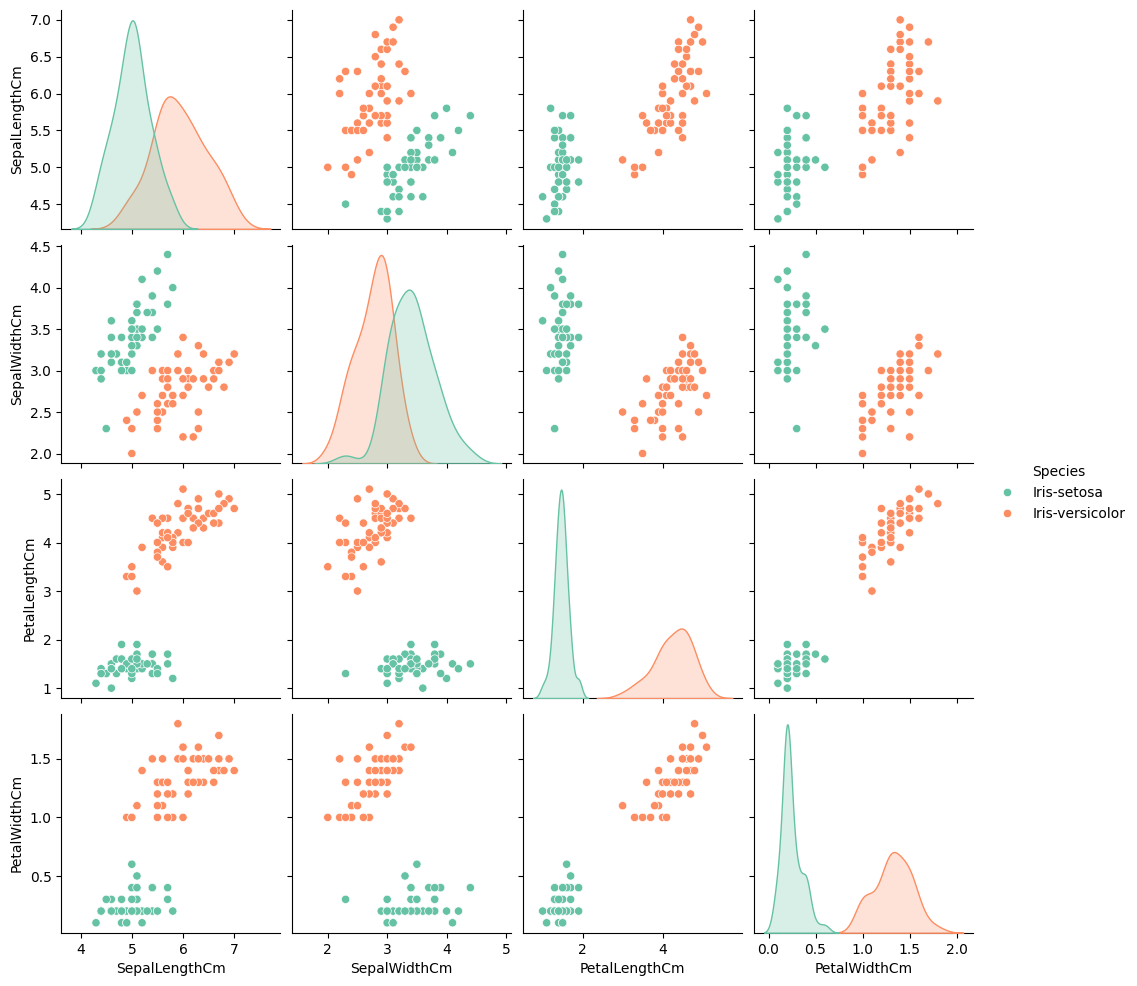

In [33]:
sns.pairplot(cleaned_data, hue="Species")

I should do:

1. use `.kdeplot` to exhibit data
2. use the ztest (Sample size greater than 30)
3. four times of analysis needed

In [25]:
setosa_sepal_length = cleaned_data.query('Species == "Iris-setosa"')["SepalLengthCm"]
versicolor_sepal_length = cleaned_data.query('Species == "Iris-versicolor"')["SepalLengthCm"]

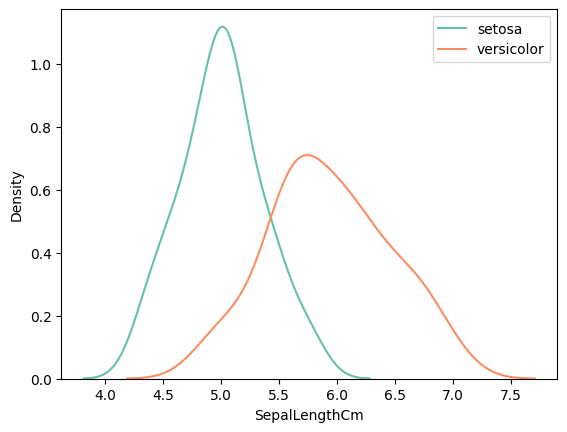

In [26]:
sns.kdeplot(setosa_sepal_length, label='setosa')
sns.kdeplot(versicolor_sepal_length, label='versicolor')

plt.legend()
plt.show()

In [30]:
alpha_two_sided = 0.05
alpha_single_side = 0.025

In [36]:
t_stat_1, p_value_1 = ttest_ind(setosa_sepal_length, versicolor_sepal_length)

print(f't统计量: {t_stat_1}\np值: {p_value_1}')

t统计量: -10.52098626754911
p值: 8.985235037487079e-18


In [32]:
if p_value_1 < alpha_two_sided:
    print("两组数据存在显著差异")
else:
    print("两组数据没有显著差异")

两组数据存在显著差异


In [37]:
setosa_sepal_width = cleaned_data.query('Species == "Iris-setosa"')["SepalWidthCm"]
versicolor_sepal_width = cleaned_data.query('Species == "Iris-versicolor"')["SepalWidthCm"]

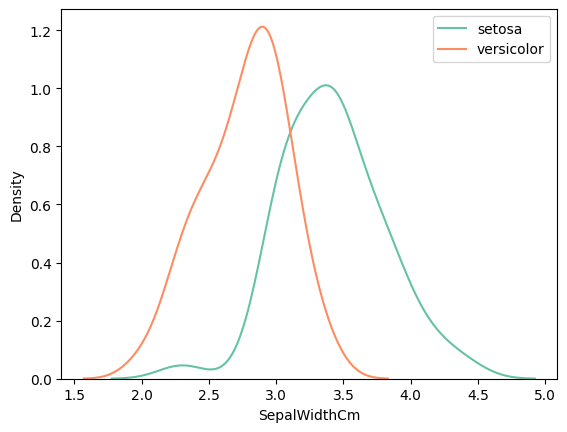

In [38]:
sns.kdeplot(setosa_sepal_width, label='setosa')
sns.kdeplot(versicolor_sepal_width, label='versicolor')

plt.legend()
plt.show()

In [39]:
t_stat_2, p_value_2 = ttest_ind(setosa_sepal_width, versicolor_sepal_width)

print(f't统计量: {t_stat_2}\np值: {p_value_2}')

t统计量: 9.282772555558111
p值: 4.362239016010215e-15


In [40]:
if p_value_2 < alpha_two_sided:
    print("两组数据存在显著差异")
else:
    print("两组数据没有显著差异")

两组数据存在显著差异
